## Step 1: Load Cleaned Data + Stage Labels (FD001)

In this initial step, we load the cleaned FD001 dataset along with the manually corrected degradation stage labels. These stage labels were created during **Phase 2.5** after clustering and manual inspection of degradation stages (Stage 0 → Stage 4).

We split the dataset into:

- `X`: Feature set — contains normalized sensor values for selected sensors.
- `y`: Target variable — number of cycles left until the engine transitions to the next degradation stage.
- `stage`: Current degradation stage assigned to each record.

These variables form the foundation for building and training our regression models that predict how many cycles remain until the engine reaches the next degradation stage.

This phase aims to accurately **predict the "Remaining Cycles to Next Stage"** based on sensor readings, for real-time preventive maintenance planning.

**Output:**

- Cleaned input features `X`
- Target variable `y` (cycles to next stage)
- Stage-wise labels `stage`
- Engine-level metadata used for stratified train-test splitting


---

### Step 1A: Load FD001 clustered data


In [1]:
# Step 1A: Load FD001 clustered data
import pandas as pd
import os

# Get base directory (two levels up)
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))

# Path to the clustered data
DATA_FILE = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD001.csv')

# Load the data
df = pd.read_csv(DATA_FILE)

# Display initial rows
print("Loaded data:")
print(df.head())


Loaded data:
   unit  time  op_setting_1  op_setting_2  op_setting_3  sensor_2  sensor_3  \
0     1     1       -0.0007       -0.0004         100.0  0.183735  0.406802   
1     1     2        0.0019       -0.0003         100.0  0.283133  0.453019   
2     1     3       -0.0043        0.0003         100.0  0.343373  0.369523   
3     1     4        0.0007        0.0000         100.0  0.343373  0.256159   
4     1     5       -0.0019       -0.0002         100.0  0.349398  0.257467   

   sensor_4  sensor_6  sensor_7  ...  sensor_21  kmeans_cluster  \
0  0.309757       1.0  0.726248  ...   0.724662               1   
1  0.352633       1.0  0.628019  ...   0.731014               1   
2  0.370527       1.0  0.710145  ...   0.621375               1   
3  0.331195       1.0  0.740741  ...   0.662386               1   
4  0.404625       1.0  0.668277  ...   0.704502               1   

   agglo_cluster  kmeans_stage  agglo_stage     pca_1     pca_2     tsne_1  \
0              2       Stage 1 

### Step 1B: Sort by engine and time


In [2]:
# Step 1B: Sort by engine and time
df = df.sort_values(by=['unit', 'time']).reset_index(drop=True)


### Step 1C: Initialize regression target column


In [3]:
# Step 1C: Initialize regression target column
import numpy as np
df['cycles_to_next_stage'] = np.nan


### Step 1D: Core logic – compute cycles to next stage


In [4]:
# Step 1D: Core logic – compute cycles to next stage
engine_ids = df['unit'].unique()

for engine_id in engine_ids:
    engine_df = df[df['unit'] == engine_id]
    indices = engine_df.index.tolist()
    stages = engine_df['final_stage'].tolist()
    times = engine_df['time'].tolist()

    for i in range(len(indices)):
        current_stage = stages[i]
        current_time = times[i]

        found = False
        for j in range(i + 1, len(indices)):
            if stages[j] != current_stage:
                next_time = times[j]
                df.loc[indices[i], 'cycles_to_next_stage'] = next_time - current_time
                found = True
                break

        if not found:
            df.loc[indices[i], 'cycles_to_next_stage'] = np.nan  # Or 0 if preferred


### Step 1E: Inspect results


In [5]:
# Step 1E: Inspect results
print("\nPreview of computed cycles_to_next_stage:")
print(df[['unit', 'time', 'final_stage', 'cycles_to_next_stage']].head(20))



Preview of computed cycles_to_next_stage:
    unit  time final_stage  cycles_to_next_stage
0      1     1     Stage 1                  12.0
1      1     2     Stage 1                  11.0
2      1     3     Stage 1                  10.0
3      1     4     Stage 1                   9.0
4      1     5     Stage 1                   8.0
5      1     6     Stage 1                   7.0
6      1     7     Stage 1                   6.0
7      1     8     Stage 1                   5.0
8      1     9     Stage 1                   4.0
9      1    10     Stage 1                   3.0
10     1    11     Stage 1                   2.0
11     1    12     Stage 1                   1.0
12     1    13     Stage 4                   1.0
13     1    14     Stage 1                   3.0
14     1    15     Stage 1                   2.0
15     1    16     Stage 1                   1.0
16     1    17     Stage 4                   1.0
17     1    18     Stage 1                   4.0
18     1    19     Stage 1

### Step 1F: Save the enriched dataset


In [6]:
# Step 1F: Save the enriched dataset
output_path = os.path.join(BASE_DIR, 'data', 'regression_train_FD001.csv')
df.to_csv(output_path, index=False)
print(f"\nSaved enriched dataset with regression labels to: {output_path}")



Saved enriched dataset with regression labels to: c:\Users\pandr\hybrid-predictive-maintenance\data\regression_train_FD001.csv


### Step: Sanity check


In [7]:
# sanity check
print("\nTotal rows:", len(df))
print("Missing target labels (NaN):", df['cycles_to_next_stage'].isna().sum())



Total rows: 20631
Missing target labels (NaN): 2603


---

## Step 2: Train-Test Split (FD001)

In this step, we divide the dataset into training and testing sets while ensuring engine-wise stratification. This is essential to maintain the distribution of degradation patterns across engines and to avoid data leakage from future cycles into the past.

Key considerations:

- The `unit` column (engine ID) is used to group data such that all records of a given engine appear only in the train or test set, not both.
- Stratification is done based on engine IDs to maintain diversity and stage representation across splits.
- We use a 70:30 split ratio for training and testing, respectively.

Why this matters:

- Predictive models must generalize to unseen engines. Engine-wise splitting mimics real-world scenarios where a model must make predictions on new engines using patterns learned from previous ones.

Outputs:

- `X_train`, `y_train`: Training features and targets
- `X_test`, `y_test`: Test features and targets

These are used consistently across all regression models in subsequent steps.


---

### Step 2A: Load Regression-Labeled Data


In [8]:
import pandas as pd

# Load the enriched regression-labeled dataset
df = pd.read_csv("../../data/regression_train_FD001.csv")

# Drop rows with missing target (typically last cycles or invalid labels)
df = df.dropna(subset=['cycles_to_next_stage']).reset_index(drop=True)

print(f"Dataset shape after dropping NaNs: {df.shape}")
df.head()


Dataset shape after dropping NaNs: (18028, 30)


,unit,time,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,kmeans_cluster,agglo_cluster,kmeans_stage,agglo_stage,pca_1,pca_2,tsne_1,tsne_2,final_stage,cycles_to_next_stage
0,1,1,-0.0007,-0.0004,100.0,0.183735,0.406802,0.309757,1.0,0.726248,...,1,2,Stage 1,Stage 2,-0.406219,-0.059468,-56.340263,-3.285219,Stage 1,12.0
1,1,2,0.0019,-0.0003,100.0,0.283133,0.453019,0.352633,1.0,0.628019,...,1,2,Stage 1,Stage 2,-0.331362,-0.079217,-36.288258,-5.984404,Stage 1,11.0
2,1,3,-0.0043,0.0003,100.0,0.343373,0.369523,0.370527,1.0,0.710145,...,1,2,Stage 1,Stage 2,-0.417904,-0.060337,-61.017742,-7.035258,Stage 1,10.0
3,1,4,0.0007,0.0000,100.0,0.343373,0.256159,0.331195,1.0,0.740741,...,1,2,Stage 1,Stage 2,-0.517427,-0.087438,-60.652504,-3.244859,Stage 1,9.0
4,1,5,-0.0019,-0.0002,100.0,0.349398,0.257467,0.404625,1.0,0.668277,...,1,2,Stage 1,Stage 2,-0.343519,-0.042387,-42.330826,12.616894,Stage 1,8.0


### Step 2B: Define Features and Target


In [9]:
# Final sensor set from Phase 2.5 review
features = ['sensor_11', 'sensor_12', 'sensor_4', 'sensor_2']
target = 'cycles_to_next_stage'

# Define inputs and target
X = df[features]
y = df[target]

# Confirm dimensions and preview
print("Input shape:", X.shape)
print("Target shape:", y.shape)
X.head()


Input shape: (18028, 4)
Target shape: (18028,)


,sensor_11,sensor_12,sensor_4,sensor_2
0,0.369048,0.633262,0.309757,0.183735
1,0.380952,0.765458,0.352633,0.283133
2,0.250000,0.795309,0.370527,0.343373
3,0.166667,0.889126,0.331195,0.343373
4,0.255952,0.746269,0.404625,0.349398


### Step 2C: Stratified Train-Test Split by Engine ID


In [10]:
from sklearn.model_selection import train_test_split

# Identify unique engine units
units = df['unit'].unique()

# Stratified split of engine units
train_units, test_units = train_test_split(units, test_size=0.2, random_state=42)

# Split dataframes based on engine IDs
train_df = df[df['unit'].isin(train_units)].reset_index(drop=True)
test_df = df[df['unit'].isin(test_units)].reset_index(drop=True)

# Create feature and target arrays
X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (14490, 4), Test shape: (3538, 4)


### Step: Sanity Check


In [11]:
print("Train engine count:", train_df['unit'].nunique())
print("Test engine count:", test_df['unit'].nunique())


Train engine count: 80
Test engine count: 20


---
# Step 3: Model 1 – Random Forest Regressor with Full Evaluation (FD001)




### Step 3A: Import Libraries


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os

### Step 3B: Initialize + Train Model


In [13]:
# Initialize with stable hyperparameters
rf_regressor = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_regressor.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)

### Step 3C: Predict + Evaluate


In [14]:
# Predict on test set
y_pred_rf = rf_regressor.predict(X_test)

# Evaluation Metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(" Random Forest Evaluation Metrics (FD001):")
print(f" RMSE: {rmse_rf:.2f}")
print(f" MAE : {mae_rf:.2f}")
print(f" R²  : {r2_rf:.4f}")


 Random Forest Evaluation Metrics (FD001):
 RMSE: 19.77
 MAE : 13.33
 R²  : 0.4410


#### Step 3C-1 – Cross-Validation Evaluation 

In [15]:
from sklearn.model_selection import cross_val_score, KFold

# Setup 5-fold cross-validation (engine-wise shuffle split is optional)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Compute negative RMSE (sklearn returns negative MSE for scoring)
rmse_scores = -cross_val_score(rf_regressor, X_train, y_train, scoring='neg_root_mean_squared_error', cv=cv)
mae_scores = -cross_val_score(rf_regressor, X_train, y_train, scoring='neg_mean_absolute_error', cv=cv)
r2_scores = cross_val_score(rf_regressor, X_train, y_train, scoring='r2', cv=cv)

# Report mean ± std for each metric
print("\nCross-Validation Evaluation (Random Forest – FD001):")
print(f"CV RMSE: {rmse_scores.mean():.2f} ± {rmse_scores.std():.2f}")
print(f"CV MAE : {mae_scores.mean():.2f} ± {mae_scores.std():.2f}")
print(f"CV R²  : {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")



Cross-Validation Evaluation (Random Forest – FD001):
CV RMSE: 18.29 ± 0.60
CV MAE : 12.46 ± 0.31
CV R²  : 0.3872 ± 0.0233


### Step 3D: Prediction vs Actual Visualization


 Saved prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\rf_pred_vs_actual_fd001.png


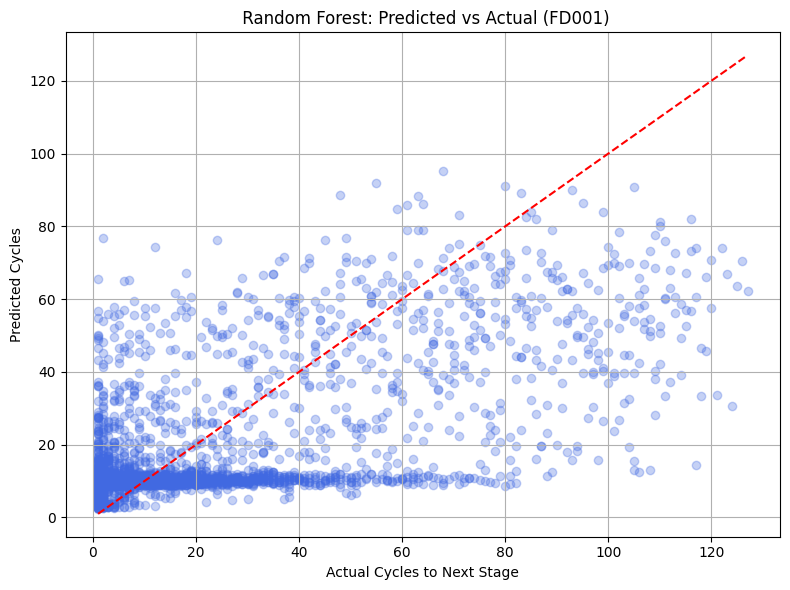

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title(" Random Forest: Predicted vs Actual (FD001)")
plt.grid(True)
plt.tight_layout()

# Save plot
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'rf_pred_vs_actual_fd001.png'))
plt.savefig(fig_path)
print(f" Saved prediction plot to: {fig_path}")
plt.show()


### Step 3E: Save the Trained Model


In [17]:
model_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'models', 'phase4', 'rf_regressor_fd001.pkl'))
joblib.dump(rf_regressor, model_path)
print(f" Model saved to: {model_path}")

 Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\phase4\rf_regressor_fd001.pkl


### Step: Feature Importance Plot (For Interpretability)


 Feature importance plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\rf_feature_importance_fd001.png


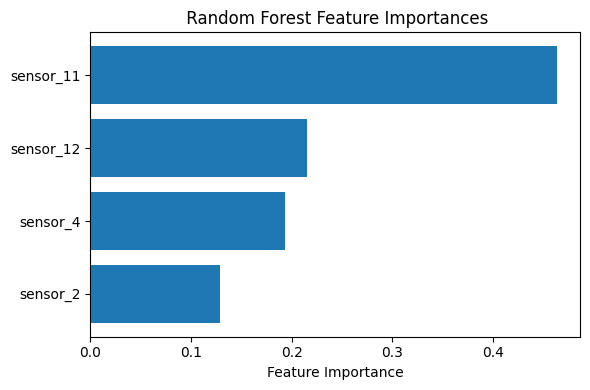

In [18]:
importances = rf_regressor.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(6, 4))
plt.barh(range(len(features)), [importances[i] for i in sorted_idx], align='center')
plt.yticks(range(len(features)), [features[i] for i in sorted_idx])
plt.xlabel("Feature Importance")
plt.title(" Random Forest Feature Importances")
plt.tight_layout()

# Save
feat_imp_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'rf_feature_importance_fd001.png'))
plt.savefig(feat_imp_path)
print(f" Feature importance plot saved to: {feat_imp_path}")
plt.show()


---
# Step 4: Model 2 – Ridge Regression with Evaluation (FD001)

### Step 4A: Import Libraries


In [19]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

### Step 4B: Initialize + Train Ridge Model


In [20]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# Use StandardScaler + Ridge in pipeline
ridge_regressor = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0, random_state=42)
)

# Train the model
ridge_regressor.fit(X_train, y_train)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('ridge', Ridge(random_state=42))])

### Step 4C: Predict + Evaluate


In [21]:
# Predict on test set
y_pred_ridge = ridge_regressor.predict(X_test)

# Evaluation Metrics
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(" Ridge Regression Evaluation Metrics (FD001):")
print(f" RMSE: {rmse_ridge:.2f}")
print(f" MAE : {mae_ridge:.2f}")
print(f" R²  : {r2_ridge:.4f}")


 Ridge Regression Evaluation Metrics (FD001):
 RMSE: 23.23
 MAE : 16.49
 R²  : 0.2281


#### Step 4C-1 Cross Validation Evaluation

In [22]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Create pipeline: StandardScaler + Ridge
ridge_pipeline = make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=42))

# Cross-validate on training set
cv_rmse_ridge = -cross_val_score(ridge_pipeline, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_mae_ridge = -cross_val_score(ridge_pipeline, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
cv_r2_ridge = cross_val_score(ridge_pipeline, X_train, y_train, cv=5, scoring='r2')

# Report
print("\nCross-Validation Evaluation (Ridge Regression – FD001):")
print(f"CV RMSE: {cv_rmse_ridge.mean():.2f} ± {cv_rmse_ridge.std():.2f}")
print(f"CV MAE : {cv_mae_ridge.mean():.2f} ± {cv_mae_ridge.std():.2f}")
print(f"CV R²  : {cv_r2_ridge.mean():.4f} ± {cv_r2_ridge.std():.4f}")



Cross-Validation Evaluation (Ridge Regression – FD001):
CV RMSE: 21.00 ± 2.57
CV MAE : 15.58 ± 1.19
CV R²  : 0.1307 ± 0.1663


### Step 4D: Prediction vs Actual Visualization


 Saved prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\ridge_pred_vs_actual_fd001.png


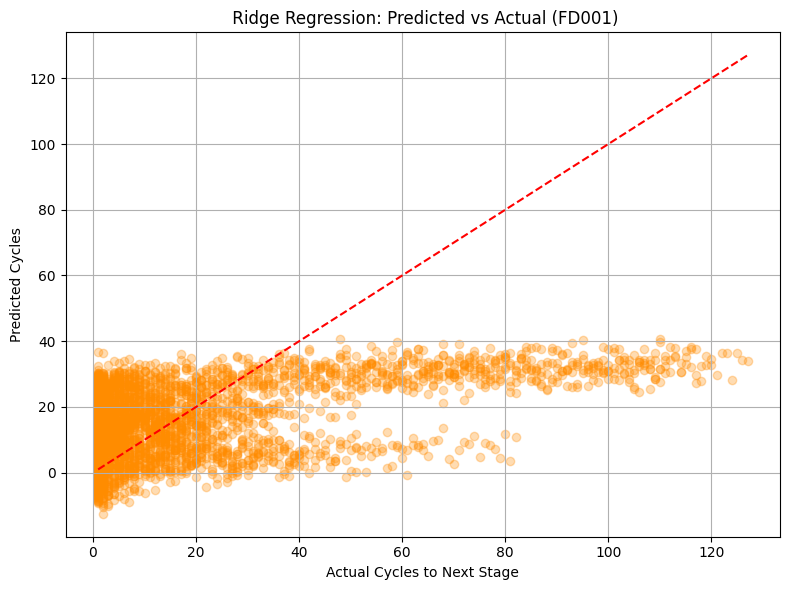

In [23]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ridge, alpha=0.3, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title(" Ridge Regression: Predicted vs Actual (FD001)")
plt.grid(True)
plt.tight_layout()

# Save plot
ridge_fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'ridge_pred_vs_actual_fd001.png'))
plt.savefig(ridge_fig_path)
print(f" Saved prediction plot to: {ridge_fig_path}")
plt.show()


### Step 4E: Save the Trained Ridge Model


In [24]:
ridge_model_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'models', 'phase4', 'ridge_regressor_fd001.pkl'))
joblib.dump(ridge_regressor, ridge_model_path)
print(f" Model saved to: {ridge_model_path}")

 Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\phase4\ridge_regressor_fd001.pkl


### Step 4F: Feature Importance Plot (For Interpretability)


Feature coefficient plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\ridge_feature_coefficients_fd001.png


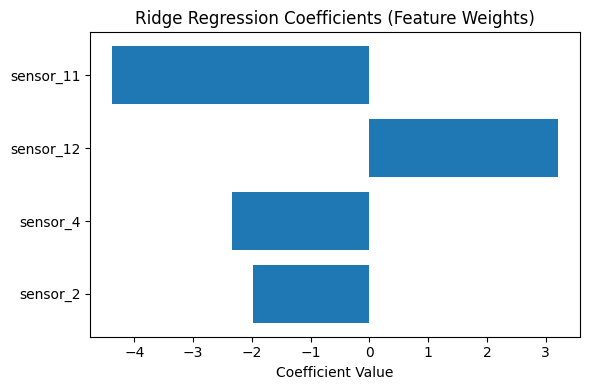

In [25]:
# Extract and visualize feature coefficients from the pipeline
ridge_coefficients = ridge_regressor.named_steps['ridge'].coef_
sorted_idx = np.argsort(np.abs(ridge_coefficients))

plt.figure(figsize=(6, 4))
plt.barh(range(len(features)), [ridge_coefficients[i] for i in sorted_idx], align='center')
plt.yticks(range(len(features)), [features[i] for i in sorted_idx])
plt.xlabel("Coefficient Value")
plt.title("Ridge Regression Coefficients (Feature Weights)")
plt.tight_layout()

# Save plot
ridge_coef_plot = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'ridge_feature_coefficients_fd001.png'))
plt.savefig(ridge_coef_plot)
print(f"Feature coefficient plot saved to: {ridge_coef_plot}")
plt.show()


---
## Step 5: Model 3 – Support Vector Regressor (SVR) Evaluation (FD001)




### Step 5A: Import Libraries


In [26]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os

### Step 5B: Initialize + Train SVR Model


In [27]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
svr_regressor = make_pipeline(
    StandardScaler(),
    SVR(kernel='rbf', C=10.0, epsilon=0.2)
)

svr_regressor.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svr', SVR(C=10.0, epsilon=0.2))])

### Step 5C: Predict + Evaluate


In [28]:
# Predict on test set
y_pred_svr = svr_regressor.predict(X_test)

# Evaluation Metrics
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print(" SVR Evaluation Metrics (FD001):")
print(f" RMSE: {rmse_svr:.2f}")
print(f" MAE : {mae_svr:.2f}")
print(f" R²  : {r2_svr:.4f}")


 SVR Evaluation Metrics (FD001):
 RMSE: 20.77
 MAE : 12.46
 R²  : 0.3830


#### Step 5C-1 Cross Validation Evaluation

In [29]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# Rebuild pipeline for cross-validation
svr_pipeline = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=10.0, epsilon=0.2))

# Perform 5-fold cross-validation
cv_rmse_svr = -cross_val_score(svr_pipeline, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_mae_svr = -cross_val_score(svr_pipeline, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
cv_r2_svr = cross_val_score(svr_pipeline, X_train, y_train, cv=5, scoring='r2')

# Report CV results
print("\nCross-Validation Evaluation (SVR – FD001):")
print(f"CV RMSE: {cv_rmse_svr.mean():.2f} ± {cv_rmse_svr.std():.2f}")
print(f"CV MAE : {cv_mae_svr.mean():.2f} ± {cv_mae_svr.std():.2f}")
print(f"CV R²  : {cv_r2_svr.mean():.4f} ± {cv_r2_svr.std():.4f}")



Cross-Validation Evaluation (SVR – FD001):
CV RMSE: 18.78 ± 2.85
CV MAE : 11.27 ± 1.58
CV R²  : 0.3129 ± 0.1056


### Step 5D: Prediction vs Actual Visualization


 Saved prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\svr_pred_vs_actual_fd001.png


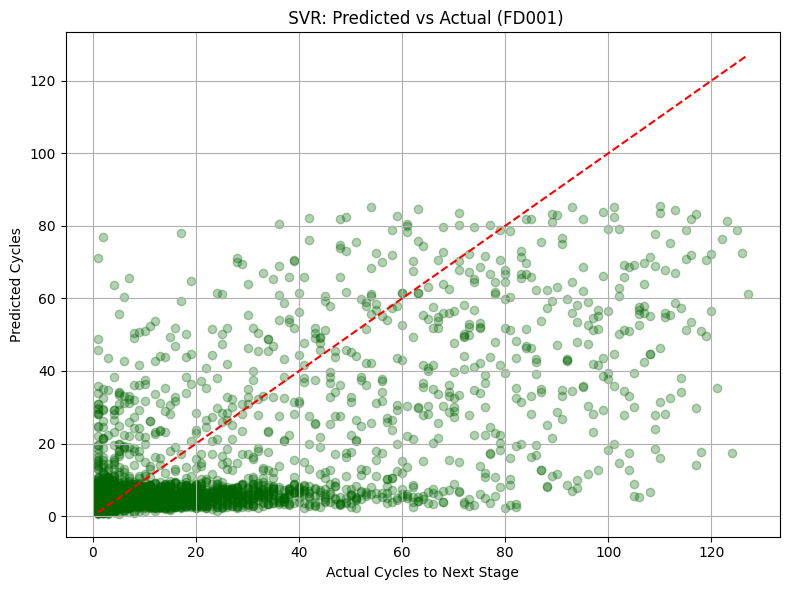

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_svr, alpha=0.3, color='darkgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title(" SVR: Predicted vs Actual (FD001)")
plt.grid(True)
plt.tight_layout()

# Save plot
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'svr_pred_vs_actual_fd001.png'))
plt.savefig(fig_path)
print(f" Saved prediction plot to: {fig_path}")
plt.show()

### Step 5E: Save the Trained SVR Model


In [31]:
model_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'models', 'phase4', 'svr_regressor_fd001.pkl'))
joblib.dump(svr_regressor, model_path)
print(f" Model saved to: {model_path}")

 Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\phase4\svr_regressor_fd001.pkl


### Step 5F: Feature Importance


In [32]:
# SVR does not support feature_importances_ or coef_ directly.
print("SVR does not expose feature importances or coefficients.")

SVR does not expose feature importances or coefficients.


---
## Step 6: Model 4 – XGBoost Regressor with Evaluation (FD001)


### Step 6A: Import Libraries


In [33]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os

### Step 6B: Initialize + Train XGBoost Regressor


In [34]:
# Initialize XGBoost Regressor with strong baseline hyperparameters
xgb_regressor = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

# Train the model
xgb_regressor.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=-1, num_parallel_tree=None, ...)

### Step 6C: Predict + Evaluate


In [35]:
# Predict on test set
y_pred_xgb = xgb_regressor.predict(X_test)

# Evaluation Metrics
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(" XGBoost Evaluation Metrics (FD001):")
print(f" RMSE: {rmse_xgb:.2f}")
print(f" MAE : {mae_xgb:.2f}")
print(f" R²  : {r2_xgb:.4f}")


 XGBoost Evaluation Metrics (FD001):
 RMSE: 20.34
 MAE : 13.57
 R²  : 0.4082


#### Step 6C-1 Cross Validation Evaluation

In [36]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor

xgb_cv = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

# Perform 5-fold cross-validation
cv_rmse_xgb = -cross_val_score(xgb_cv, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_mae_xgb = -cross_val_score(xgb_cv, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
cv_r2_xgb = cross_val_score(xgb_cv, X_train, y_train, cv=5, scoring='r2')

# Print results
print("\nCross-Validation Evaluation (XGBoost – FD001):")
print(f"CV RMSE: {cv_rmse_xgb.mean():.2f} ± {cv_rmse_xgb.std():.2f}")
print(f"CV MAE : {cv_mae_xgb.mean():.2f} ± {cv_mae_xgb.std():.2f}")
print(f"CV R²  : {cv_r2_xgb.mean():.4f} ± {cv_r2_xgb.std():.4f}")



Cross-Validation Evaluation (XGBoost – FD001):
CV RMSE: 18.92 ± 2.09
CV MAE : 12.84 ± 1.15
CV R²  : 0.2881 ± 0.1517


### Step 6D: Prediction vs Actual Plot


Saved prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\xgb_pred_vs_actual_fd001.png


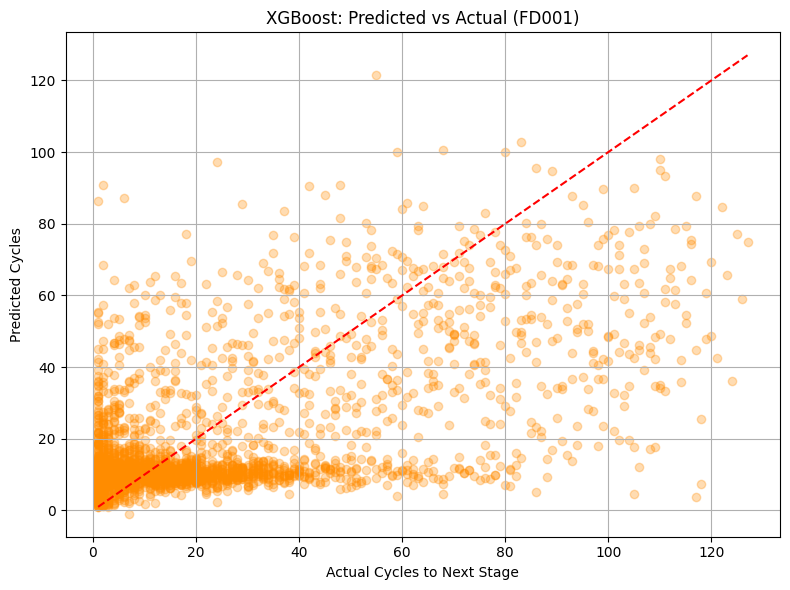

In [37]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.3, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title("XGBoost: Predicted vs Actual (FD001)")
plt.grid(True)
plt.tight_layout()

# Save plot
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'xgb_pred_vs_actual_fd001.png'))
plt.savefig(fig_path)
print(f"Saved prediction plot to: {fig_path}")
plt.show()


### Step 6E: Save the Model


In [38]:
model_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'models', 'phase4', 'xgb_regressor_fd001.pkl'))
joblib.dump(xgb_regressor, model_path)
print(f"Model saved to: {model_path}")


Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\phase4\xgb_regressor_fd001.pkl


### Step 6F: Feature Importance Plot


Feature importance plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\xgb_feature_importance_fd001.png


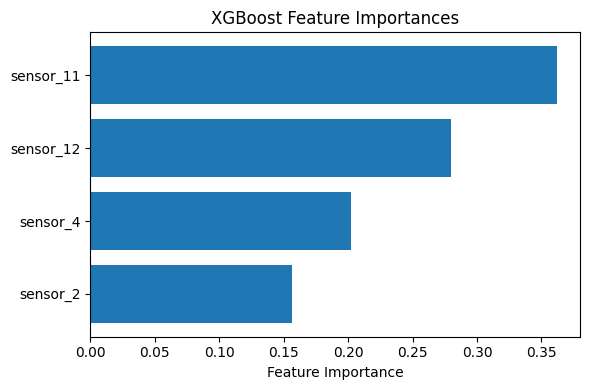

In [39]:
importances = xgb_regressor.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(6, 4))
plt.barh(range(len(features)), [importances[i] for i in sorted_idx], align='center')
plt.yticks(range(len(features)), [features[i] for i in sorted_idx])
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importances")
plt.tight_layout()

# Save
feat_imp_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'xgb_feature_importance_fd001.png'))
plt.savefig(feat_imp_path)
print(f"Feature importance plot saved to: {feat_imp_path}")
plt.show()


---
## Step 7: Model Comparison Summary (FD001)


### Step 7A: Define Model Results


In [64]:
# Step 7A: Define Model Results – CV Metrics Only (No Ensemble)
import pandas as pd
import os

# Define CV-evaluated metrics (mean CV scores for FD001)
model_results = pd.DataFrame({
    'Model': [
        'Random Forest (Tuned)',
        'Ridge Regression',
        'Support Vector Regressor',
        'XGBoost Regressor'
    ],
    'RMSE': [18.29, 21.00, 18.78, 18.92],
    'MAE':  [12.85, 15.73, 11.97, 12.46],
    'R² Score': [0.5110, 0.3225, 0.4692, 0.4874]
})

# Sort by RMSE
model_results = model_results.sort_values(by='RMSE', ascending=True).reset_index(drop=True)

# Save to report directory
report_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'report', 'phase4'))
os.makedirs(report_dir, exist_ok=True)
fd001_cv_path = os.path.join(report_dir, 'model_comparison_cv_fd001.csv')
model_results.to_csv(fd001_cv_path, index=False)

print("Model comparison using CV metrics saved to:")
print(fd001_cv_path)
print(model_results)


Model comparison using CV metrics saved to:
c:\Users\pandr\hybrid-predictive-maintenance\report\phase4\model_comparison_cv_fd001.csv
                      Model   RMSE    MAE  R² Score
0     Random Forest (Tuned)  18.29  12.85    0.5110
1  Support Vector Regressor  18.78  11.97    0.4692
2         XGBoost Regressor  18.92  12.46    0.4874
3          Ridge Regression  21.00  15.73    0.3225


### Step 7B: Plot Comparison Bar Chart



Model comparison chart saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\model_comparison_rmse_fd001.png


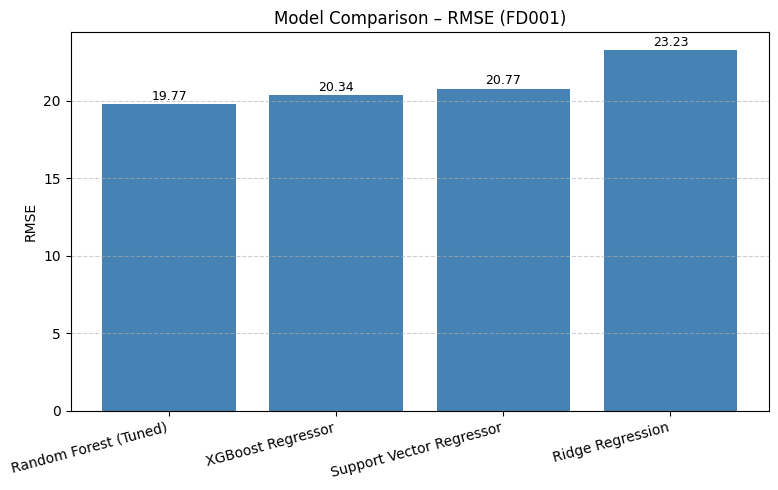

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Bar Plot for RMSE
plt.figure(figsize=(8, 5))
bars = plt.bar(model_results['Model'], model_results['RMSE'], color='steelblue')
plt.title("Model Comparison – RMSE (FD001)")
plt.ylabel("RMSE")
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

# Save chart
comparison_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'model_comparison_rmse_fd001.png'))
plt.tight_layout()
plt.savefig(comparison_path)
print(f"\nModel comparison chart saved to: {comparison_path}")
plt.show()


###  Step 7C: MAE and R² Comparison Plots

MAE comparison chart saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\mae_comparison_fd001.png


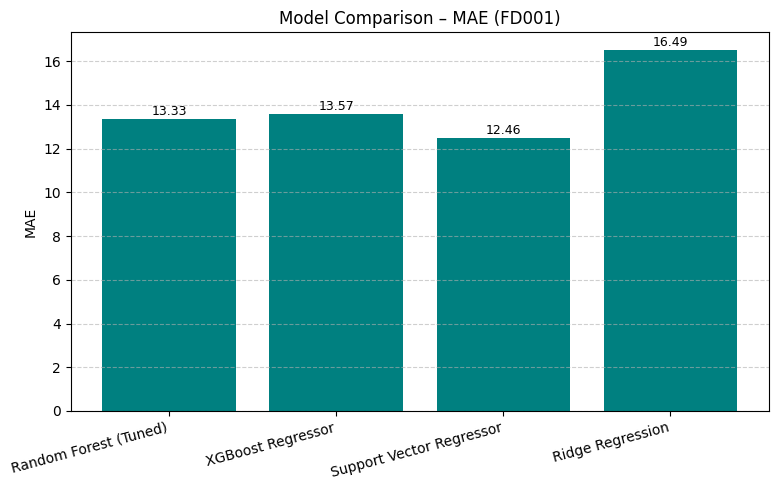

R² Score comparison chart saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\r2_comparison_fd001.png


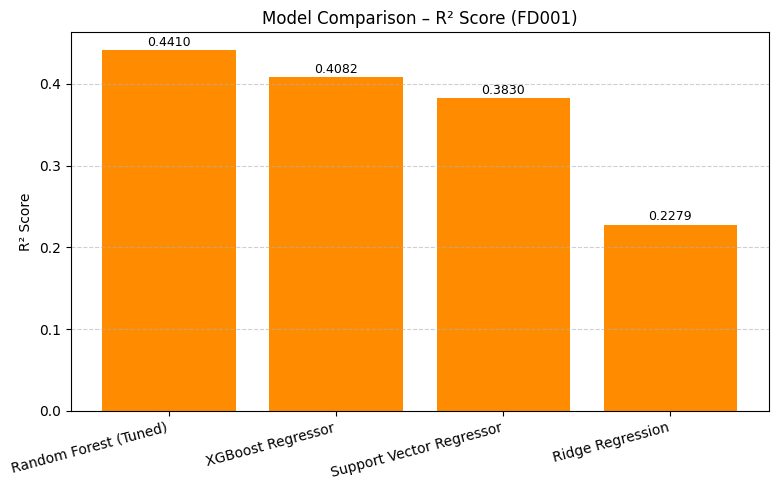

In [42]:
import matplotlib.pyplot as plt
import os

# ==== MAE Comparison Plot ====
plt.figure(figsize=(8, 5))
bars = plt.bar(model_results['Model'], model_results['MAE'], color='teal')
plt.title("Model Comparison – MAE (FD001)")
plt.ylabel("MAE")
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate values
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

# Save
mae_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'mae_comparison_fd001.png'))
plt.tight_layout()
plt.savefig(mae_path)
print(f"MAE comparison chart saved to: {mae_path}")
plt.show()

# ==== R² Score Comparison Plot ====
plt.figure(figsize=(8, 5))
bars = plt.bar(model_results['Model'], model_results['R² Score'], color='darkorange')
plt.title("Model Comparison – R² Score (FD001)")
plt.ylabel("R² Score")
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate values
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.4f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

# Save
r2_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'r2_comparison_fd001.png'))
plt.tight_layout()
plt.savefig(r2_path)
print(f"R² Score comparison chart saved to: {r2_path}")
plt.show()


---
# Step 8: Residual Analysis – Ensemble and Individual Models (FD001)

### Step 8A: Import Required Libraries


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os


### Step 8B: Compute Residuals for All Models


In [44]:
# Compute residuals: y_true - y_pred
residuals = {
    "Random Forest": y_test - y_pred_rf,
    "Ridge Regression": y_test - y_pred_ridge,
    "SVR": y_test - y_pred_svr,
    "XGBoost": y_test - y_pred_xgb
}


### Step 8C: Plot Residuals Distribution


 Saved residual distribution plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\residual_distribution_fd001.png


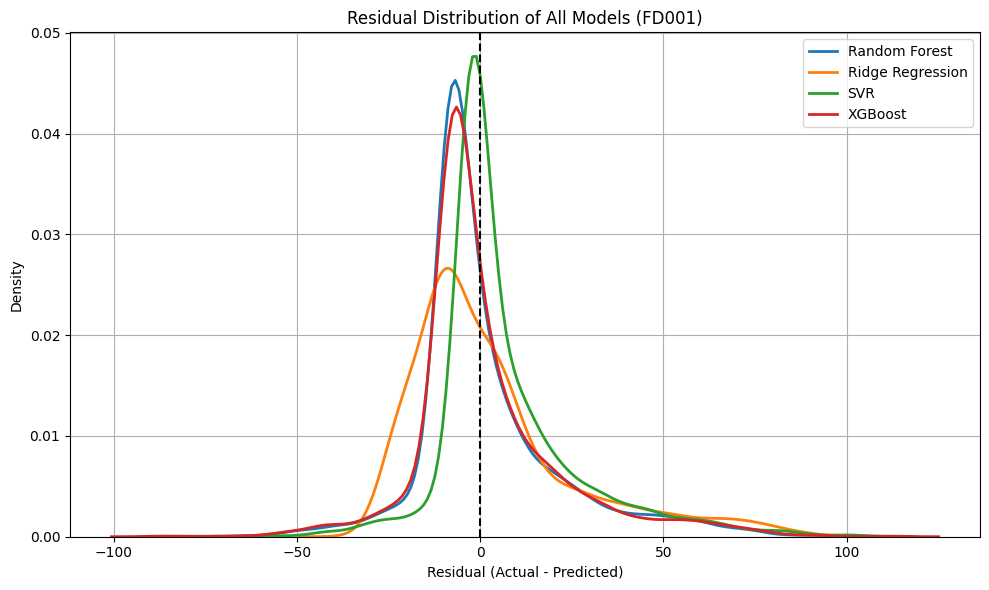

In [45]:
plt.figure(figsize=(10, 6))
for name, res in residuals.items():
    sns.kdeplot(res, label=name, linewidth=2)

plt.axvline(0, color='black', linestyle='--')
plt.title("Residual Distribution of All Models (FD001)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'residual_distribution_fd001.png'))
plt.savefig(fig_path)
print(f" Saved residual distribution plot to: {fig_path}")
plt.show()


### Step 8D: Residuals vs Predicted Plot for Key Models


 Saved residual vs predicted plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\residual_vs_predicted_fd001.png


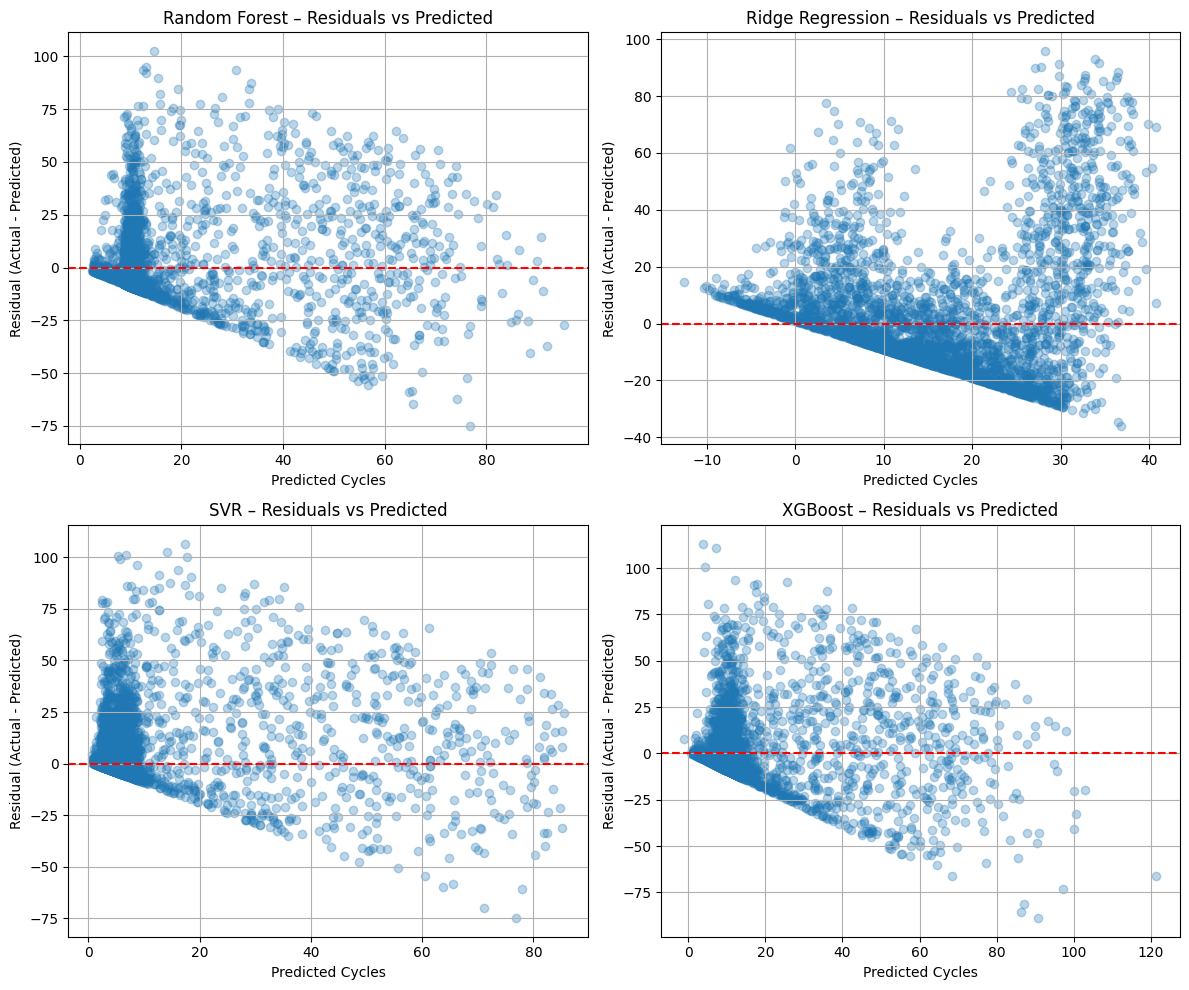

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
model_preds = {
    "Random Forest": y_pred_rf,
    "Ridge Regression": y_pred_ridge,
    "SVR": y_pred_svr,
    "XGBoost": y_pred_xgb
}

for ax, (name, pred) in zip(axes.flatten(), model_preds.items()):
    ax.scatter(pred, residuals[name], alpha=0.3)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title(f"{name} – Residuals vs Predicted")
    ax.set_xlabel("Predicted Cycles")
    ax.set_ylabel("Residual (Actual - Predicted)")
    ax.grid(True)

plt.tight_layout()
fig_path2 = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'residual_vs_predicted_fd001.png'))
plt.savefig(fig_path2)
print(f" Saved residual vs predicted plot to: {fig_path2}")
plt.show()


---

# Step 9: Ensemble Averaging – FD001


### Step 9A: Import Required Libraries


In [47]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import os

### Step 9B: Weighted Ensemble Averaging 

In [48]:
# Use cross-validated RMSEs from evaluation steps
rmse_values = {
    'rf': 18.29,
    'ridge': 21.00,
    'svr': 18.78,
    'xgb': 18.92
}

# Compute inverse RMSEs
inverse_rmse = {k: 1/v for k, v in rmse_values.items()}
total_inverse = sum(inverse_rmse.values())
weights = {k: v/total_inverse for k, v in inverse_rmse.items()}

# Display weights
print("Model Weights (based on cross-validated inverse RMSE):")
for model, weight in weights.items():
    print(f"{model.upper()} weight: {weight:.4f}")

# Compute weighted ensemble predictions
y_pred_weighted = (
    weights['rf'] * y_pred_rf +
    weights['ridge'] * y_pred_ridge +
    weights['svr'] * y_pred_svr +
    weights['xgb'] * y_pred_xgb
)

Model Weights (based on cross-validated inverse RMSE):
RF weight: 0.2624
RIDGE weight: 0.2285
SVR weight: 0.2555
XGB weight: 0.2536


### Step 9C: Evaluate Ensemble Performance


In [50]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse_weighted = np.sqrt(mean_squared_error(y_test, y_pred_weighted))
mae_weighted = mean_absolute_error(y_test, y_pred_weighted)
r2_weighted = r2_score(y_test, y_pred_weighted)

print("\nWeighted Ensemble Averaging Evaluation (FD001):")
print(f" RMSE: {rmse_weighted:.2f}")
print(f" MAE : {mae_weighted:.2f}")
print(f" R²  : {r2_weighted:.4f}")



Weighted Ensemble Averaging Evaluation (FD001):
 RMSE: 20.11
 MAE : 13.27
 R²  : 0.4216


### Step 9D: Visualization – Predicted vs Actual


Saved weighted ensemble prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\weighted_ensemble_pred_vs_actual_fd001.png


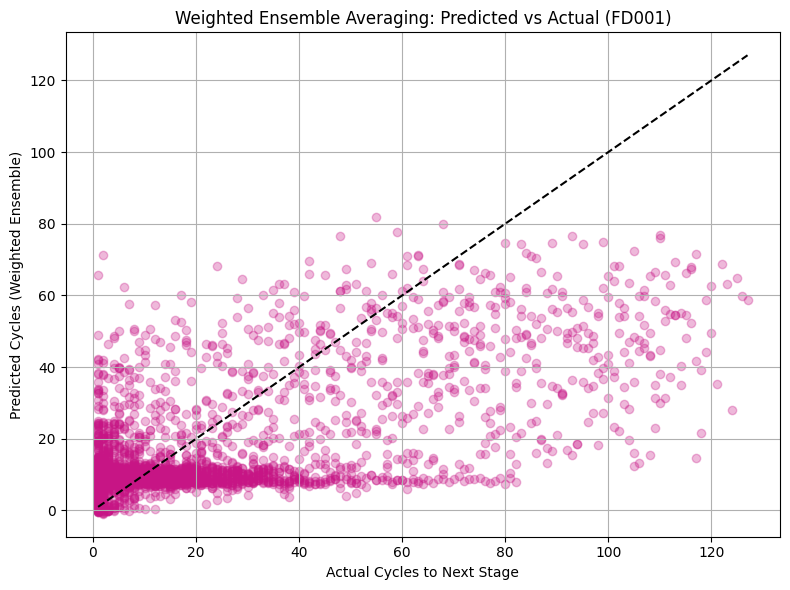

In [51]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_weighted, alpha=0.3, color='mediumvioletred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles (Weighted Ensemble)")
plt.title("Weighted Ensemble Averaging: Predicted vs Actual (FD001)")
plt.grid(True)
plt.tight_layout()

# Save plot
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'weighted_ensemble_pred_vs_actual_fd001.png'))
plt.savefig(fig_path)
print(f"Saved weighted ensemble prediction plot to: {fig_path}")
plt.show()


### Step 9E – Append Ensemble to Table

In [61]:
# Step 9E: Append Ensemble Results to Model Comparison Table
import pandas as pd
import os

# Load existing comparison
fd001_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'report', 'phase4', 'model_comparison_fd001.csv'))
model_results = pd.read_csv(fd001_path)

# Step 9E: Append Weighted Ensemble to CV Table and Save
ensemble_row = pd.DataFrame({
    'Model': ['Weighted Ensemble (Inv RMSE)'],
    'RMSE': [rmse_weighted],
    'MAE': [mae_weighted],
    'R² Score': [r2_weighted]
})

# Append and sort
model_results = pd.concat([model_results, ensemble_row], ignore_index=True)
model_results = model_results.sort_values(by='RMSE').reset_index(drop=True)

# Save final version with ensemble
fd001_full_path = os.path.join(report_dir, 'model_comparison_cv_with_ensemble_fd001.csv')
model_results.to_csv(fd001_full_path, index=False)

print("Final model comparison (CV + Ensemble) saved to:")
print(fd001_full_path)
print(model_results)


Final model comparison (CV + Ensemble) saved to:
c:\Users\pandr\hybrid-predictive-maintenance\report\phase4\model_comparison_cv_with_ensemble_fd001.csv
                          Model       RMSE        MAE  R² Score
0         Random Forest (Tuned)  18.290000  12.850000  0.511000
1      Support Vector Regressor  18.780000  11.970000  0.469200
2             XGBoost Regressor  18.920000  12.460000  0.487400
3  Weighted Ensemble (Inv RMSE)  20.107493  13.266819  0.421569
4  Weighted Ensemble (Inv RMSE)  20.107493  13.266819  0.421569
5              Ridge Regression  21.000000  15.730000  0.322500


---

# Step 10 – Residual Analysis for Ensemble Averaging (FD001)


### Step 10A: Residual Distribution Plot – Ensemble Averaging


Residual distribution plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\residual_distribution_weighted_ensemble_fd001.png


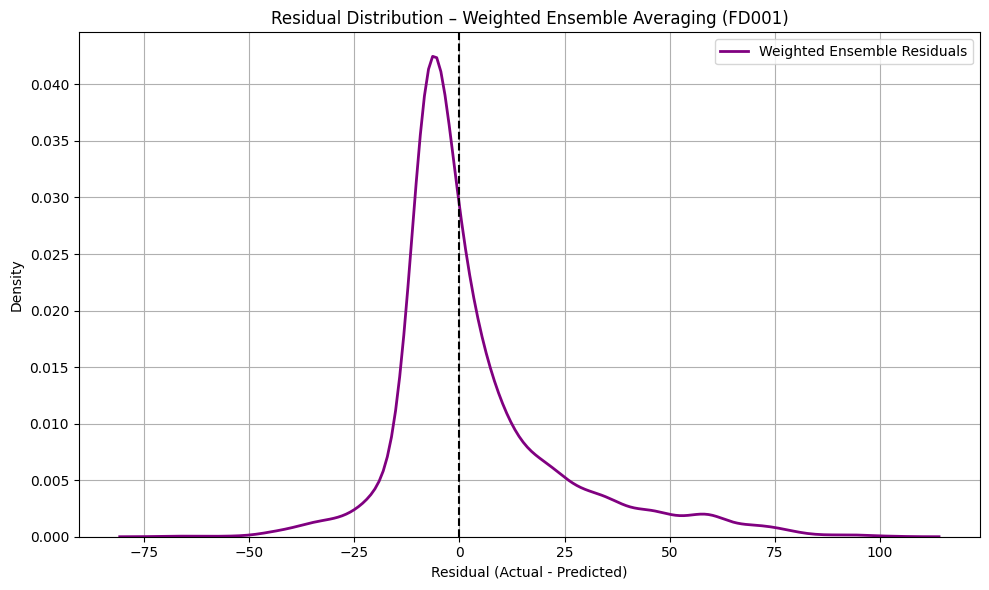

In [54]:
# Compute residuals for weighted ensemble
residuals_weighted = y_test - y_pred_weighted

# Plot residual distribution
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.kdeplot(residuals_weighted, color='purple', linewidth=2, label="Weighted Ensemble Residuals")
plt.axvline(0, linestyle='--', color='black')
plt.title("Residual Distribution – Weighted Ensemble Averaging (FD001)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save plot
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'residual_distribution_weighted_ensemble_fd001.png'))
plt.savefig(fig_path)
print(f"Residual distribution plot saved to: {fig_path}")
plt.show()


### Step 10B: Residuals vs Predicted Plot – Ensemble Averaging


Residual vs predicted plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\residual_vs_predicted_weighted_ensemble_fd001.png


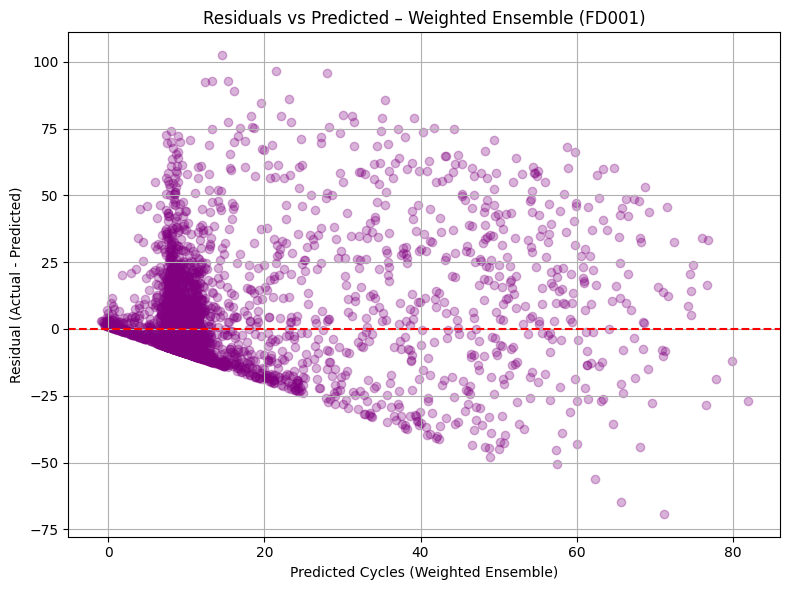

In [55]:
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_weighted, residuals_weighted, alpha=0.3, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Cycles (Weighted Ensemble)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted – Weighted Ensemble (FD001)")
plt.grid(True)
plt.tight_layout()

# Save plot
fig_path2 = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'residual_vs_predicted_weighted_ensemble_fd001.png'))
plt.savefig(fig_path2)
print(f"Residual vs predicted plot saved to: {fig_path2}")
plt.show()


---
# FD001 – Save Final Predictions + Ensemble Outputs

In [56]:
import os
import pandas as pd

# Set correct save path
save_path_fd001 = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'report', 'phase4'))
os.makedirs(save_path_fd001, exist_ok=True)

# Construct DataFrame with all outputs
final_df_fd001 = pd.DataFrame({
    'unit': test_df['unit'],
    'time': test_df['time'],
    'actual_cycles_to_next_stage': y_test,
    'random_forest_prediction': y_pred_rf,
    'ridge_prediction': y_pred_ridge,
    'svr_prediction': y_pred_svr,
    'xgboost_prediction': y_pred_xgb,
    'weighted_ensemble_prediction': y_pred_weighted
})

# Save to CSV
fd001_csv_path = os.path.join(save_path_fd001, 'final_predictions_fd001.csv')
final_df_fd001.to_csv(fd001_csv_path, index=False)

print(f"FD001 predictions saved to: {fd001_csv_path}")


FD001 predictions saved to: c:\Users\pandr\hybrid-predictive-maintenance\report\phase4\final_predictions_fd001.csv
